# Plot Figure S13 - Gradients

This notebook generates the main data figure comparing fluorescent gradients in HQNO and RHL reporters for different PA strains (WT and those deficient in HQNO and or RHL production).

Code for the additional figure panels, containing model fitting, are provided in complimentary [Github Repository](https://github.com/simonvanvliet/SpatialToleranceModel)  

In [1]:
# Data analysis packages
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Visualization packages
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 8
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

COLORS_H = {
    'wt':          '#ffcc66',
    '∆pqsL':       '#669966',
    '∆pqsL ∆rhlA': '#9999B3',
}

COLORS_R = {
    'wt':          '#ffcc66',
    '∆rhlA':       '#cc99ff',
    '∆rhlA ∆pqsL': '#9999B3',
}

# =============================================================================
# LOAD DATA
# =============================================================================

df_hqno_raw = pd.read_csv('../analysis_code/0_combined_df_hqno.csv')
df_rhl_raw  = pd.read_csv('../analysis_code/0_combined_df_rhl.csv')

# =============================================================================
# PROCESSING FUNCTIONS
# =============================================================================

def preprocess_data(df, color_channel='gfp', correction_quantile=0.0):
    """Convert pixel coordinates to µm, rename the intensity column, and apply
    per-chamber background correction (subtract the correction_quantile-th
    quantile of cell-level intensity within each strain × chamber group).

    Returns a copy of df with columns:
        x_um, y_um, chamber_id, intensity, corrected_intensity
    """
    df = df.copy()
    pixel_to_um = 0.065
    df['x_um'] = df['x'] * pixel_to_um
    df['y_um'] = df['y'] * pixel_to_um
    df['chamber_id'] = df['replicate'].astype(str) + '_' + df['pos'].astype(str)
    df = df.rename(columns={f'intensity_raw_{color_channel}': 'intensity'})

    baseline = df.groupby(['strain', 'chamber_id'])['intensity'].transform(
        lambda x: x.quantile(correction_quantile)
    )
    df['corrected_intensity'] = df['intensity'] - baseline
    return df


def bin_continuous(df):
    """Bin preprocessed data into 1.5-µm-wide bins (0–54 µm) and compute the
    median intensity per bin per chamber.

    Returns a dataframe with one row per (strain, replicate, pos, y_bin) with
    columns: y_um (bin centre), chamber_id, intensity (median), corrected_intensity (median).
    """
    df = df.copy()
    y_bins = np.linspace(0, 54, 37)          # 36 bins × 1.5 µm
    y_bin_centers = (y_bins[:-1] + y_bins[1:]) / 2
    num_y_bins = len(y_bins) - 1

    df['y_bin'] = np.digitize(df['y_um'], y_bins, right=False) - 1
    df['y_bin'] = df['y_bin'].clip(0, num_y_bins - 1)

    df_data = (
        df.groupby(['strain', 'replicate', 'pos', 'y_bin'])[['intensity', 'corrected_intensity']]
        .median()
        .reset_index()
    )
    df_data['y_um'] = y_bin_centers[df_data['y_bin'].values]
    df_data['chamber_id'] = df_data['replicate'].astype(str) + '_' + df_data['pos'].astype(str)
    return df_data


def bin_discrete(df, nbins=3):
    """Assign each cell to spatial bins by equal-width cuts on y_um and compute
    the median intensity per bin per chamber.

    nbins=3 produces Back / Middle / Opening bins plus an 'All' aggregate.
    nbins=1 produces only an 'All' aggregate (all positions combined).

    Returns a dataframe with columns:
        strain, replicate, pos, chamber_id, y_bin_label, intensity, corrected_intensity
    """
    df = df.copy()
    if nbins == 3:
        bin_map = {0: 'Back', 1: 'Middle', 2: 'Opening'}
        df['y_bin'] = pd.cut(df['y_um'], bins=3, labels=False, include_lowest=True).astype(int)
        df['y_bin_label'] = df['y_bin'].map(bin_map)

        df_all = df.copy()
        df_all['y_bin'] = -1
        df_all['y_bin_label'] = 'All'

        df_combined = pd.concat([df, df_all], ignore_index=True)

    elif nbins == 1:
        df['y_bin'] = 0
        df['y_bin_label'] = 'All'
        df_combined = df

    else:
        raise ValueError("Unsupported number of bins. Only nbins=1 or nbins=3 are supported.")

    df_data = (
        df_combined.groupby(['strain', 'replicate', 'pos', 'y_bin_label'])[['intensity', 'corrected_intensity']]
        .median()
        .reset_index()
    )
    df_data['chamber_id'] = df_data['replicate'].astype(str) + '_' + df_data['pos'].astype(str)
    return df_data


# =============================================================================
# PROCESS DATA
# =============================================================================

df_hqno = preprocess_data(df_hqno_raw, color_channel='gfp',     correction_quantile=0.01)
df_rhl  = preprocess_data(df_rhl_raw,  color_channel='mcherry', correction_quantile=0.01)

df_hqno_profile = bin_continuous(df_hqno)
df_rhl_profile  = bin_continuous(df_rhl)

df_hqno_binned = bin_discrete(df_hqno, nbins=1)
df_rhl_binned  = bin_discrete(df_rhl, nbins=1)


Statistical comparisons (HQNO) — intensity  [all positions combined]
  Bonferroni correction: 3 pairwise comparison(s)
  One-way ANOVA: F=62.438, p=0.0000
  wt vs ∆pqsL: t=7.993, p=0.0000, p_bonf=0.0000  ***
  wt vs ∆pqsL ∆rhlA: t=7.817, p=0.0000, p_bonf=0.0000  ***
  ∆pqsL vs ∆pqsL ∆rhlA: t=3.300, p=0.0021, p_bonf=0.0062  **

Statistical comparisons (RHL) — intensity  [all positions combined]
  Bonferroni correction: 3 pairwise comparison(s)
  One-way ANOVA: F=71.989, p=0.0000
  wt vs ∆rhlA: t=7.816, p=0.0000, p_bonf=0.0000  ***
  wt vs ∆rhlA ∆pqsL: t=9.196, p=0.0000, p_bonf=0.0000  ***
  ∆rhlA vs ∆rhlA ∆pqsL: t=3.593, p=0.0009, p_bonf=0.0026  **


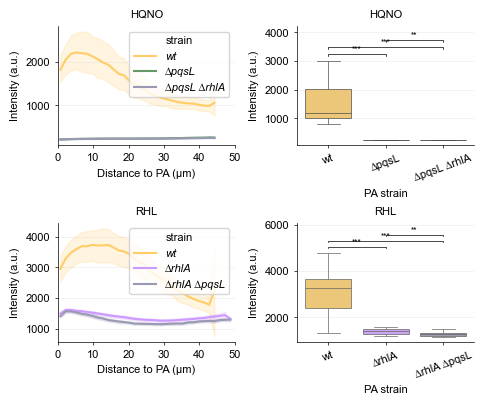


Statistical comparisons (HQNO) — corrected_intensity  [all positions combined]
  Bonferroni correction: 3 pairwise comparison(s)
  One-way ANOVA: F=32.509, p=0.0000
  wt vs ∆pqsL: t=5.768, p=0.0000, p_bonf=0.0000  ***
  wt vs ∆pqsL ∆rhlA: t=5.640, p=0.0000, p_bonf=0.0000  ***
  ∆pqsL vs ∆pqsL ∆rhlA: t=2.924, p=0.0057, p_bonf=0.0172  *

Statistical comparisons (RHL) — corrected_intensity  [all positions combined]
  Bonferroni correction: 3 pairwise comparison(s)
  One-way ANOVA: F=72.676, p=0.0000
  wt vs ∆rhlA: t=8.105, p=0.0000, p_bonf=0.0000  ***
  wt vs ∆rhlA ∆pqsL: t=8.951, p=0.0000, p_bonf=0.0000  ***
  ∆rhlA vs ∆rhlA ∆pqsL: t=0.720, p=0.4757, p_bonf=1.0000  ns


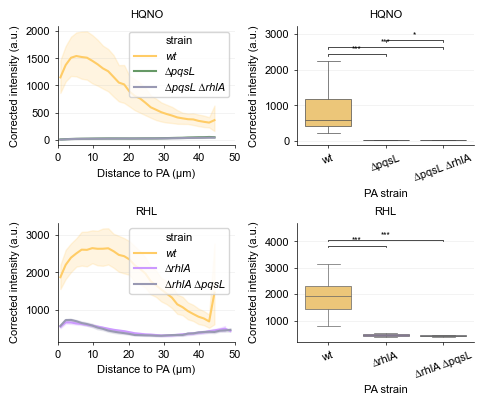

In [3]:
# =============================================================================
# STATISTICS HELPERS
# =============================================================================

def _sig_symbol(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return None   # not significant — no annotation


def _bonferroni(p_val, n_comparisons):
    """Apply Bonferroni correction to a single p-value."""
    return min(p_val * n_comparisons, 1.0)


def _valid_pairs(df, strain_order):
    """Return pairwise combinations restricted to strains present in df with ≥2 observations."""
    present = set(df['strain'].unique())
    active = [s for s in strain_order if s in present]
    return [(active[i], active[j])
            for i in range(len(active))
            for j in range(i + 1, len(active))]


def print_strain_stats(df, y_col, strain_order, label=''):
    """Print pairwise t-tests (Bonferroni-corrected) and one-way ANOVA comparing
    strains across all chamber positions combined (matching the style used in
    FigureS7/S7C).  Both raw and Bonferroni-corrected p-values are reported."""
    pairs = _valid_pairs(df, strain_order)
    n_comp = len(pairs)

    print(f"\n{'='*70}")
    print(f"Statistical comparisons ({label}) — {y_col}  [all positions combined]")
    print(f"  Bonferroni correction: {n_comp} pairwise comparison(s)")
    print(f"{'='*70}")

    present = [s for s in strain_order if s in set(df['strain'].unique())]
    groups = [df[df['strain'] == h][y_col].dropna().values for h in present]
    if len(groups) > 1 and all(len(g) > 1 for g in groups):
        f_stat, p_anova = stats.f_oneway(*groups)
        print(f"  One-way ANOVA: F={f_stat:.3f}, p={p_anova:.4f}")

    for h1, h2 in pairs:
        g1 = df[df['strain'] == h1][y_col].dropna()
        g2 = df[df['strain'] == h2][y_col].dropna()
        if len(g1) < 2 or len(g2) < 2:
            continue
        t_stat, p_raw = stats.ttest_ind(g1, g2)
        p_bonf = _bonferroni(p_raw, n_comp)
        sym = _sig_symbol(p_bonf) or 'ns'
        print(f"  {h1} vs {h2}: t={t_stat:.3f}, p={p_raw:.4f}, p_bonf={p_bonf:.4f}  {sym}")


def annotate_strain_stats(ax, df, y_col, strain_order):
    """Add significance bars above pairwise strain comparisons on a boxplot where
    x='strain' (one box per strain, positions at integers 0, 1, 2, …).
    Significance is assessed on Bonferroni-corrected p-values.
    Only significant pairs (p_bonf < 0.05) are drawn.
    """
    pairs = _valid_pairs(df, strain_order)
    n_comp = len(pairs)

    data_max = df[y_col].quantile(0.95)
    data_min = df[y_col].quantile(0.05)
    step = (data_max - data_min) * 0.10

    # Whisker-top per strain (Q3 + 1.5 × IQR, capped at actual max)
    whisker_tops = {}
    for h in strain_order:
        vals = df[df['strain'] == h][y_col].dropna()
        if len(vals):
            q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
            whisker_tops[h] = min(q3 + 1.5 * (q3 - q1), vals.max())
    base_y = max(whisker_tops.values()) if whisker_tops else data_max

    for k, (h1, h2) in enumerate(pairs):
        g1 = df[df['strain'] == h1][y_col].dropna()
        g2 = df[df['strain'] == h2][y_col].dropna()
        if len(g1) < 2 or len(g2) < 2:
            continue
        _, p_raw = stats.ttest_ind(g1, g2)
        p_bonf = _bonferroni(p_raw, n_comp)
        sym = _sig_symbol(p_bonf)
        if sym is None:
            continue

        x1 = strain_order.index(h1)
        x2 = strain_order.index(h2)
        y_bar = base_y + step * (k + 1)

        ax.plot([x1, x1, x2, x2],
                [y_bar - step * 0.25, y_bar, y_bar, y_bar - step * 0.25],
                lw=0.5, color='black', clip_on=False)
        ax.text((x1 + x2) / 2, y_bar + step * 0.05, sym,
                ha='center', va='bottom', fontsize=6, clip_on=False)

    # Expand y-axis to accommodate all annotation bars
    current_top = ax.get_ylim()[1]
    needed_top = base_y + step * (len(pairs) + 2)
    ax.set_ylim(top=max(current_top, needed_top))


# =============================================================================
# PLOT
# =============================================================================

def _style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.tick_params(axis='both', which='major', width=0.5, length=2, labelsize=8)
    ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)
    legend = ax.get_legend()
    if legend is not None:
        legend.get_title().set_fontstyle('normal')
        for text in legend.get_texts():
            text.set_fontstyle('italic')


INTENSITY_SETTINGS = [
    ('intensity',           'Intensity (a.u.)',           'S13_gradients.pdf'),
    ('corrected_intensity', 'Corrected intensity (a.u.)', 'S13_gradients_corrected.pdf'),
]

for intensity_col, ylabel, output_file in INTENSITY_SETTINGS:

    fig, axs = plt.subplots(2, 2,
                            figsize=(2 * 6 / 2.54, 2 * 5 / 2.54),
                            constrained_layout=True)

    strain_order_h = list(COLORS_H.keys())
    strain_order_r = list(COLORS_R.keys())

    # All-positions combined subsets (the 'All' pseudo-bin)
    df_hq_all = df_hqno_binned[df_hqno_binned['y_bin_label'] == 'All'].copy()
    df_rhl_all = df_rhl_binned[df_rhl_binned['y_bin_label'] == 'All'].copy()

    # --- Panel [0,0]: HQNO continuous gradient ---
    sns.lineplot(data=df_hqno_profile, x='y_um', y=intensity_col,
                 hue='strain', palette=COLORS_H, errorbar='ci', ax=axs[0][0])
    axs[0][0].set_title('HQNO', fontsize=8)
    axs[0][0].set_xlabel('Distance to PA (µm)', fontsize=8)
    axs[0][0].set_ylabel(ylabel, fontsize=8)
    axs[0][0].set_xlim(0, 50)
    axs[0][0].set_xticks([0, 10, 20, 30, 40, 50])

    # --- Panel [0,1]: HQNO box plot (all positions combined, x = strain) ---
    sns.boxplot(data=df_hq_all, x='strain', y=intensity_col,
                order=strain_order_h, hue='strain', hue_order=strain_order_h,
                palette=COLORS_H, showfliers=False, linewidth=0.5,
                legend=False, ax=axs[0][1])
    annotate_strain_stats(axs[0][1], df_hq_all, intensity_col, strain_order_h)
    print_strain_stats(df_hq_all, intensity_col, strain_order_h, label='HQNO')
    axs[0][1].set_title('HQNO', fontsize=8)
    axs[0][1].set_xlabel('PA strain', fontsize=8)
    axs[0][1].set_ylabel(ylabel, fontsize=8)
    axs[0][1].tick_params(axis='x', labelrotation=20)

    # --- Panel [1,0]: RHL continuous gradient ---
    sns.lineplot(data=df_rhl_profile, x='y_um', y=intensity_col,
                 hue='strain', palette=COLORS_R, errorbar='ci', ax=axs[1][0])
    axs[1][0].set_title('RHL', fontsize=8)
    axs[1][0].set_xlabel('Distance to PA (µm)', fontsize=8)
    axs[1][0].set_ylabel(ylabel, fontsize=8)
    axs[1][0].set_xlim(0, 50)
    axs[1][0].set_xticks([0, 10, 20, 30, 40, 50])

    # --- Panel [1,1]: RHL box plot (all positions combined, x = strain) ---
    sns.boxplot(data=df_rhl_all, x='strain', y=intensity_col,
                order=strain_order_r, hue='strain', hue_order=strain_order_r,
                palette=COLORS_R, showfliers=False, linewidth=0.5,
                legend=False, ax=axs[1][1])
    annotate_strain_stats(axs[1][1], df_rhl_all, intensity_col, strain_order_r)
    print_strain_stats(df_rhl_all, intensity_col, strain_order_r, label='RHL')
    axs[1][1].set_title('RHL', fontsize=8)
    axs[1][1].set_xlabel('PA strain', fontsize=8)
    axs[1][1].set_ylabel(ylabel, fontsize=8)
    axs[1][1].tick_params(axis='x', labelrotation=20)

    for ax in axs.flatten():
        _style_ax(ax)

    #plt.savefig(output_file, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()

In [48]:
print(df_hqno_profile['replicate'].unique())
print(df_rhl_profile['replicate'].unique())
print(df_hqno_profile['chamber_id'].unique())
print(df_rhl_profile['chamber_id'].unique())

<ArrowStringArray>
['replicate_1', 'replicate_2']
Length: 2, dtype: str
<ArrowStringArray>
['replicate_1', 'replicate_2']
Length: 2, dtype: str
<ArrowStringArray>
[ 'replicate_1_pos0',  'replicate_1_pos1', 'replicate_1_pos10',
 'replicate_1_pos11',  'replicate_1_pos2',  'replicate_1_pos3',
  'replicate_1_pos4',  'replicate_1_pos5',  'replicate_1_pos6',
  'replicate_1_pos7',  'replicate_1_pos8',  'replicate_1_pos9',
  'replicate_2_pos0',  'replicate_2_pos1',  'replicate_2_pos2',
  'replicate_2_pos3',  'replicate_2_pos4',  'replicate_2_pos5',
  'replicate_2_pos6',  'replicate_2_pos7',  'replicate_2_pos8',
  'replicate_2_pos9']
Length: 22, dtype: str
<ArrowStringArray>
[ 'replicate_1_pos0',  'replicate_1_pos1',  'replicate_1_pos2',
  'replicate_1_pos3',  'replicate_1_pos4',  'replicate_1_pos5',
  'replicate_1_pos6',  'replicate_1_pos7',  'replicate_1_pos8',
  'replicate_1_pos9',  'replicate_2_pos0',  'replicate_2_pos1',
  'replicate_2_pos2',  'replicate_2_pos3',  'replicate_2_pos4',
  're